# **Librerías**

## Instalación

In [2]:
!pip install geopandas

In [3]:
!pip install ydata_profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 33.7 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=c3fb8e4fa8f5dc4732cdd7a5d78203d2496c4128e13bd46dd14451f67c848301
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


## Importación

In [4]:
import os
import warnings
from datetime import datetime
from unicodedata import normalize

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [7]:
import geopandas as gdp
from ydata_profiling import ProfileReport

In [8]:
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 2)

# **Lectura de datos**

## Drive specific

In [9]:
from google.colab import drive

In [10]:
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
os.chdir('/content/drive/MyDrive/Grupo DM/Datasets')

## Creación de dfs

In [12]:
df = pd.read_csv('urbania_data.csv')   #Lectura del dataset principal
df.head()

,Unnamed: 0.1,Unnamed: 0,Antiguedad,Anunciante,Balneario,NroBanios,Nro_pisos,Cocheras,Descripcion,Direccion,...,'Aire acondicionado','Amoblado','Sauna','Calefaccion','Equipado','Terma','Portero electrico','Cocina con reposteros',Distrito,Provincia
0,0,3,5.0,Valentinoinmobiliaria,Nulo,4.0,2.0,3.0,excelente opcion para vivir en una de las mej...,"Malecon Monte Bello 5 La Molina, La Planicie, ...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LaMolina,Lima
1,1,4,5.0,No disponible,Nulo,5.0,3.0,1.0,hermosa casa a espalda de futura avenida prol...,Mz. O2 Lt. 03 Urb. San Antonio De Carapongo 2 ...,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Lurigancho,Lima
2,2,5,3.0,No disponible,Nulo,5.0,3.0,4.0,casa de estreno acabados de primera. calle ce...,"El Pinar 120 , La Planicie 1era Etapa La Molin...",...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,LaMolina,Lima
3,5,8,1.0,No disponible,Sol Y Mar,5.0,2.0,3.0,linda casa en condominio con piscina club hou...,"Km 98.5 De La Panamericana Sur Asia, Sol Y Mar...",...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Asia,Lima
4,6,9,4.0,No disponible,Nulo,4.0,2.0,2.0,monterrico 2 casas en 1 ( casa bajos 4 dormit...,"Mariano De Rivera Y Ustariz #215 Surco, Huerto...",...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,SantiagoDeSurco,Lima


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7663 entries, 0 to 7662
Data columns (total 96 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0.1                    7663 non-null   int64  
 1   Unnamed: 0                      7663 non-null   int64  
 2   Antiguedad                      7663 non-null   float64
 3   Anunciante                      7663 non-null   object 
 4   Balneario                       7663 non-null   object 
 5   NroBanios                       7663 non-null   float64
 6   Nro_pisos                       7663 non-null   float64
 7   Cocheras                        7663 non-null   float64
 8   Descripcion                     7663 non-null   object 
 9   Direccion                       7663 non-null   object 
 10  Dormitorios                     7663 non-null   object 
 11  Estado de Inmueble              7663 non-null   object 
 12  Fecha_pub                       76

In [14]:
crimen = pd.read_csv('distritos_crimen.csv', encoding='utf-8')  #Cantidad de crimenes por distrito
crimen.head()


,Distrito,Cantidad
0,Lima,13948
1,Los Olivos,13090
2,San Juan de Lurigancho,12159
3,San Martín de Porres,9093
4,Comas,9051


In [15]:
crimen.shape

(50, 2)

In [16]:
superficie = pd.read_csv('distritos_km2.csv')                   #Area por distrito
superficie.head()

,Distrito,Km2
0,Carabayllo,346.9
1,Ancón,299.2
2,Cieneguilla,240.3
3,Lurigancho-Chosica,236.5
4,Lurín,181.1


In [17]:
superficie.shape

(43, 2)

In [18]:
colegios = pd.read_excel('listado_iiee.xlsx')     #Colegios por distrito
colegios.head()

,Código Modular,Anexo,Nombre de SS.EE.,Ubigeo,Departamento,Provincia,Distrito,Código DRE/UGEL,DRE / UGEL,Centro Poblado,Código Centro Poblado,Código Local,Dirección,Nivel / Modalidad,Gestion / Dependencia,Latitud,Longitud,Altitud,Fuente de coordenadas
0,1066216,0,AMAUTA,150101,LIMA,LIMA,LIMA,150101,DRE LIMA METROPOLITANA,CERCADO DE LIMA,536990,290641.0,AVENIDA 9 DE DICIEMBRE 321,Superior Pedagógica,Privada - Particular,-12.06,-77.04,139,UBICACION_WEB (LOCAL)
1,1723352,0,INNOVA SCHOOLS - BERTELLO,150101,LIMA,LIMA,LIMA,150104,03 BREÑA,FUNDO CHACRARIO,567819,805206.0,SUB LOTE 5-B MZ C LOTE 3-4-5,Inicial - Jardín,Privada - Particular,-12.06,-77.06,104,UBICACION_WEB_MED (LOCAL)
2,1723360,0,INNOVA SCHOOLS - BERTELLO,150101,LIMA,LIMA,LIMA,150104,03 BREÑA,FUNDO CHACRARIO,567819,805206.0,SUB LOTE 5-B MZ C LOTE 3-4-5,Primaria,Privada - Particular,-12.06,-77.06,104,UBICACION_WEB_MED (LOCAL)
3,1723378,0,INNOVA SCHOOLS - BERTELLO,150101,LIMA,LIMA,LIMA,150104,03 BREÑA,FUNDO CHACRARIO,567819,805206.0,SUB LOTE 5-B MZ C LOTE 3-4-5,Secundaria,Privada - Particular,-12.06,-77.06,104,UBICACION_WEB_MED (LOCAL)
4,1798958,0,ODEC CASTRENSE,150101,LIMA,LIMA,LIMA,150104,03 BREÑA,LIMA,523312,862904.0,AVENIDA AREQUIPA 1032,Instancia de Apoyo,Pública - En convenio,-12.05,-77.03,156,MED-GPS (CP)


In [19]:
colegios.shape

(16550, 19)

In [20]:
empresas = pd.read_csv('distritos_densidad_empresarial.csv')
empresas.head()

,Distrito,Empresas_por_km2
0,La Victoria,6456.4
1,Surquillo,4130.9
2,Lince,3996.4
3,Cercado de Lima,3502.9
4,Breña,3400.6


In [21]:
empresas.shape

(49, 2)

In [22]:
mapa = gdp.read_file('distritos_peru.geojson')
mapa.head()

,geo_point_2d,ccdd,nombdep,ccpp,nombprov,ccdi,nombdist,capital,ubigeo,idprov,codigo,cnt_ccpp,descripcio,poblacion,fecha,dat_pob,geometry
0,"{ ""lon"": -79.160978376900005, ""lat"": -7.117980...",06,CAJAMARCA,11,SAN MIGUEL,10,SAN GREGORIO,SAN GREGORIO,061110,0611,061110,48,SAN GREGORIO,2278.0,2020.0,INEI,"POLYGON ((-79.08233 -7.00544, -79.08041 -7.005..."
1,"{ ""lon"": -79.815788072700002, ""lat"": -6.930483...",14,LAMBAYEQUE,01,CHICLAYO,03,ETEN,ETEN,140103,1401,140103,8,ETEN,13020.0,2020.0,INEI,"POLYGON ((-79.84212 -6.87952, -79.84169 -6.879..."
2,"{ ""lon"": -79.904259754799995, ""lat"": -6.880746...",14,LAMBAYEQUE,01,CHICLAYO,14,SANTA ROSA,SANTA ROSA,140114,1401,140114,3,SANTA ROSA,13568.0,2020.0,INEI,"POLYGON ((-79.89631 -6.84974, -79.89438 -6.850..."
3,"{ ""lon"": -76.986687032299997, ""lat"": -10.75640...",15,LIMA,09,OYON,03,CAUJUL,CAUJUL,150903,1509,150903,18,CAUJUL,633.0,2020.0,INEI,"POLYGON ((-76.99089 -10.68093, -76.98723 -10.6..."
4,"{ ""lon"": -77.742165930100001, ""lat"": -10.48644...",15,LIMA,02,BARRANCA,02,PARAMONGA,PARAMONGA,150202,1502,150202,54,PARAMONGA,25510.0,2020.0,INEI,"POLYGON ((-77.73974 -10.32098, -77.73849 -10.3..."


In [23]:
mapa.shape

(1875, 17)

# **Preprocesamiento**

## Preparación inicial dfs

In [24]:
def transformar_distrito(distrito: str) -> str:
  distrito = normalize('NFKD', distrito.title()).encode('ascii','ignore')
  distrito = distrito.decode('ascii')
  return distrito.replace(' ', '')

In [25]:
df = df[df.columns[2:]]
df.head()

,Antiguedad,Anunciante,Balneario,NroBanios,Nro_pisos,Cocheras,Descripcion,Direccion,Dormitorios,Estado de Inmueble,...,'Aire acondicionado','Amoblado','Sauna','Calefaccion','Equipado','Terma','Portero electrico','Cocina con reposteros',Distrito,Provincia
0,5.0,Valentinoinmobiliaria,Nulo,4.0,2.0,3.0,excelente opcion para vivir en una de las mej...,"Malecon Monte Bello 5 La Molina, La Planicie, ...",3,Excelente,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LaMolina,Lima
1,5.0,No disponible,Nulo,5.0,3.0,1.0,hermosa casa a espalda de futura avenida prol...,Mz. O2 Lt. 03 Urb. San Antonio De Carapongo 2 ...,5+,Excelente,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Lurigancho,Lima
2,3.0,No disponible,Nulo,5.0,3.0,4.0,casa de estreno acabados de primera. calle ce...,"El Pinar 120 , La Planicie 1era Etapa La Molin...",4,Excelente,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,LaMolina,Lima
3,1.0,No disponible,Sol Y Mar,5.0,2.0,3.0,linda casa en condominio con piscina club hou...,"Km 98.5 De La Panamericana Sur Asia, Sol Y Mar...",4,Excelente,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Asia,Lima
4,4.0,No disponible,Nulo,4.0,2.0,2.0,monterrico 2 casas en 1 ( casa bajos 4 dormit...,"Mariano De Rivera Y Ustariz #215 Surco, Huerto...",5+,Muy bueno,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,SantiagoDeSurco,Lima


In [26]:
df.columns = [col.strip("' ") for col in df.columns]
df.columns

Index(['Antiguedad', 'Anunciante', 'Balneario', 'NroBanios', 'Nro_pisos',
       'Cocheras', 'Descripcion', 'Direccion', 'Dormitorios',
       'Estado de Inmueble', 'Fecha_pub', 'Luminosidad', 'Mascotas', 'Precio',
       'Tipo', 'TipoCochera', 'Ubicacion', 'Uso_comercial', 'Uso_profesional',
       'latitud', 'longitud', 'Area_constr', 'Area_total', 'Area_constr_m2',
       'Area_total_m2', 'match', 'Cuarto de servicio', 'Deposito', 'Terraza',
       'Kitchenette', 'Sala de estar', 'Sotano', 'Patio', 'anx81tico',
       'Comedor diario', 'Comedor', 'Banio de servicio', 'Jardanxadn Interno',
       'Walking Closet', 'Escritorio', 'Cocina', 'Banio independiente',
       'Lavanderanxada', 'Balcon', 'Sala', 'Closet', 'Banio de visitas',
       'Agua', 'Guardiananxada', 'Internet', 'Luz', 'Cable',
       'Servicio de Limpieza', 'Conexion a gas', 'Sistema de seguridad',
       'Telefono', 'Areadeportiva', 'Piscina', 'Solarium', 'Sala de internet',
       'Sala de cine', 'Jardanxadn', 'Parqu

In [27]:
superficie.loc[:,'Distrito'] = superficie.loc[:,'Distrito'].apply(transformar_distrito)
superficie.head()

,Distrito,Km2
0,Carabayllo,346.9
1,Ancon,299.2
2,Cieneguilla,240.3
3,Lurigancho-Chosica,236.5
4,Lurin,181.1


In [28]:
crimen.loc[:,'Distrito'] = crimen.loc[:,'Distrito'].apply(transformar_distrito)
crimen.head()

,Distrito,Cantidad
0,Lima,13948
1,LosOlivos,13090
2,SanJuanDeLurigancho,12159
3,SanMartinDePorres,9093
4,Comas,9051


In [29]:
empresas.loc[:,'Distrito'] = empresas.loc[:,'Distrito'].apply(transformar_distrito)
empresas.head()

,Distrito,Empresas_por_km2
0,LaVictoria,6456.4
1,Surquillo,4130.9
2,Lince,3996.4
3,CercadoDeLima,3502.9
4,Brena,3400.6


In [30]:
colegios.sample(4)

,Código Modular,Anexo,Nombre de SS.EE.,Ubigeo,Departamento,Provincia,Distrito,Código DRE/UGEL,DRE / UGEL,Centro Poblado,Código Centro Poblado,Código Local,Dirección,Nivel / Modalidad,Gestion / Dependencia,Latitud,Longitud,Altitud,Fuente de coordenadas
7718,1057256,0,INDEPENDENCIA,150122,LIMA,LIMA,MIRAFLORES,150108,07 SAN BORJA,MIRAFLORES,529304,317080.0,AVENIDA PASEO DE LA REPUBLICA 4900,Inicial - Jardín,Privada - Particular,-12.11,-77.03,98,UGELCENSO_GPS (LOCAL)
10095,1470772,0,EDMUND TAYLOR WHITTAKER,150132,LIMA,LIMA,SAN JUAN DE LURIGANCHO,150106,05 SAN JUAN DE LURIGANCHO,SAN JUAN DE LURIGANCHO,550652,574041.0,MZ BJ LOTE 17,Secundaria,Privada - Particular,-11.92,-76.97,516,UBICACION_WEB (LOCAL)
10110,582107,0,EL BOSQUECITO,150132,LIMA,LIMA,SAN JUAN DE LURIGANCHO,150106,05 SAN JUAN DE LURIGANCHO,SAN JUAN DE LURIGANCHO,552734,NaN,JIRON LOS PASOS S/N,Inicial No Escolarizado,Pública - Sector Educación,-11.95,-76.99,345,MED_REG (LOCAL)
2112,775908,0,3054 LA FLOR,150106,LIMA,LIMA,CARABAYLLO,150105,04 COMAS,CARABAYLLO,115388,296860.0,JIRON INDUSTRIAL 291,Secundaria,Pública - Sector Educación,-11.90,-77.03,218,UBICACION_WEB (LOCAL)


In [31]:
colegios.loc[:, 'Distrito'] = colegios.loc[:,'Distrito'].apply(transformar_distrito)
colegios['tipo colegio'] = colegios['Nivel / Modalidad'].str.split(' - ').apply(lambda x: x[0])
colegios = colegios.pivot_table(values='Código Modular', index='Distrito', columns='tipo colegio', aggfunc='count')
colegios = colegios.fillna(0).astype(np.int16)
colegios.head()

tipo colegio,Básica Alternativa,Básica Especial,Escuela Superior Pedagógica,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
Distrito,,,,,,,,,,,,,
Ancon,6,1,0,0,43,28,0,39,17,0,0,0,2
Ate,52,4,0,0,435,90,1,362,203,1,1,4,19
Barranco,11,4,0,0,23,8,1,21,17,0,0,3,2
Brena,7,2,1,0,47,1,1,45,33,0,1,3,12
Carabayllo,18,4,0,0,241,99,0,206,124,0,0,2,4


In [32]:
mapa.sample(3)

,geo_point_2d,ccdd,nombdep,ccpp,nombprov,ccdi,nombdist,capital,ubigeo,idprov,codigo,cnt_ccpp,descripcio,poblacion,fecha,dat_pob,geometry
892,"{ ""lon"": -74.409840063199994, ""lat"": -13.69028...",05,AYACUCHO,10,VICTOR FAJARDO,11,SARHUA,SARHUA,051011,0510,051011,32,SARHUA,2701.0,2020.0,INEI,"POLYGON ((-74.43498 -13.58784, -74.43436 -13.5..."
1556,"{ ""lon"": -72.042300147099994, ""lat"": -13.50191...",08,CUSCO,01,CUSCO,03,POROY,POROY,080103,0801,080103,17,POROY,2732.0,2020.0,INEI,"POLYGON ((-72.02282 -13.47805, -72.02271 -13.4..."
1172,"{ ""lon"": -70.302360422500001, ""lat"": -16.08027...",21,PUNO,01,PUNO,13,SAN ANTONIO,SAN ANTONIO DE ESQUILACHE /14,210113,2101,210113,80,SAN ANTONIO,2688.0,2020.0,INEI,"POLYGON ((-70.16174 -15.97937, -70.15927 -15.9..."


In [33]:
mapa = mapa[mapa['nombprov'] == 'LIMA']
mapa = mapa.rename(columns={'nombdist': 'Distrito'})
mapa.loc[:, 'Distrito'] = mapa.loc[:,'Distrito'].apply(transformar_distrito)
mapa = mapa[['Distrito', 'poblacion', 'geometry', 'geo_point_2d']]
mapa.head()

,Distrito,poblacion,geometry,geo_point_2d
157,Lurigancho,230978.0,"POLYGON ((-76.90063 -12.01454, -76.90082 -12.0...","{ ""lon"": -76.794207352000001, ""lat"": -11.95574..."
158,SanBorja,134317.0,"POLYGON ((-76.9872 -12.08007, -76.98711 -12.08...","{ ""lon"": -76.995262726899995, ""lat"": -12.09753..."
159,SanMiguel,175411.0,"POLYGON ((-77.0791 -12.06032, -77.07905 -12.06...","{ ""lon"": -77.090089642300001, ""lat"": -12.07659..."
160,Rimac,190288.0,"POLYGON ((-77.03077 -11.99708, -77.03059 -11.9...","{ ""lon"": -77.032587905200003, ""lat"": -12.02359..."
161,Independencia,230144.0,"POLYGON ((-77.02872 -11.96252, -77.02872 -11.9...","{ ""lon"": -77.046008436500003, ""lat"": -11.98747..."


## Unir tablas

In [34]:
df = mapa.merge(df, 'right', 'Distrito')
df = df.merge(superficie, 'left', 'Distrito')
df = df.merge(crimen, 'left', 'Distrito')
df = df.merge(empresas, 'left', 'Distrito')
df = df.merge(colegios, 'left', 'Distrito')
df.head()

,Distrito,poblacion,geometry,geo_point_2d,Antiguedad,Anunciante,Balneario,NroBanios,Nro_pisos,Cocheras,...,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
0,LaMolina,166442.0,"POLYGON ((-76.94449 -12.05684, -76.9441 -12.05...","{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",5.0,Valentinoinmobiliaria,Nulo,4.0,2.0,3.0,...,1.0,113.0,0.0,0.0,66.0,60.0,0.0,1.0,2.0,4.0
1,Lurigancho,230978.0,"POLYGON ((-76.90063 -12.01454, -76.90082 -12.0...","{ ""lon"": -76.794207352000001, ""lat"": -11.95574...",5.0,No disponible,Nulo,5.0,3.0,1.0,...,0.0,175.0,62.0,0.0,144.0,96.0,0.0,0.0,3.0,12.0
2,LaMolina,166442.0,"POLYGON ((-76.94449 -12.05684, -76.9441 -12.05...","{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",3.0,No disponible,Nulo,5.0,3.0,4.0,...,1.0,113.0,0.0,0.0,66.0,60.0,0.0,1.0,2.0,4.0
3,Asia,NaN,None,NaN,1.0,No disponible,Sol Y Mar,5.0,2.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SantiagoDeSurco,410587.0,"POLYGON ((-76.95961 -12.07575, -76.95938 -12.0...","{ ""lon"": -76.984518805600004, ""lat"": -12.12722...",4.0,No disponible,Nulo,4.0,2.0,2.0,...,1.0,214.0,46.0,0.0,126.0,90.0,0.0,1.0,8.0,14.0


In [35]:
df.shape

(7663, 113)

## **EDA**

In [36]:
#Estadisticas descriptivas
df.describe().round(2)

,poblacion,Antiguedad,NroBanios,Nro_pisos,Cocheras,Precio,latitud,longitud,Area_constr_m2,match,...,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
count,6.19e+03,7663.00,7663.00,7663.00,7663.0,7.66e+03,7663.00,7663.00,7663.00,7663.0,...,6187.00,6187.00,6187.00,6187.00,6187.00,6187.00,6187.00,6187.00,6187.00,6187.00
mean,2.39e+05,3.08,3.82,2.31,2.4,8.74e+05,-12.02,-76.93,356.48,0.0,...,0.69,142.33,25.23,0.16,96.28,69.21,0.03,0.82,4.80,8.68
std,1.90e+05,1.91,1.08,0.67,1.5,6.56e+06,1.22,1.20,242.04,0.0,...,0.56,106.81,37.04,0.44,93.65,55.22,0.18,0.62,3.73,6.74
min,1.09e+03,1.00,1.00,1.00,0.0,2.20e+04,-34.60,-81.26,1.00,0.0,...,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,1.34e+05,2.00,3.00,2.00,1.0,3.10e+05,-12.13,-77.01,225.00,0.0,...,0.00,57.00,0.00,0.00,39.00,25.00,0.00,1.00,2.00,4.00
50%,1.66e+05,3.00,4.00,2.00,2.0,5.80e+05,-12.09,-76.96,313.00,0.0,...,1.00,113.00,2.00,0.00,66.00,60.00,0.00,1.00,3.00,5.00
75%,3.62e+05,4.00,5.00,3.00,4.0,9.95e+05,-12.08,-76.91,430.00,0.0,...,1.00,214.00,46.00,0.00,126.00,90.00,0.00,1.00,8.00,14.00
max,1.15e+06,9.00,5.00,8.00,8.0,5.70e+08,-0.00,0.00,8000.00,0.0,...,3.00,596.00,182.00,2.00,533.00,342.00,1.00,4.00,15.00,36.00


In [37]:
# Exploración inicial
#profile = ProfileReport(df[df.columns.drop(['geometry', 'geo_point_2d'])])
#profile.to_notebook_iframe()

## Limpieza

Columnas poco útiles

In [38]:
df.drop(columns=[
    'Anunciante', 'Descripcion', 'Direccion', 'TipoCochera',
    'Ubicacion', 'Area_constr', 'Area_total', 'match'],
        inplace=True)
df.shape

(7663, 105)

Duplicados

In [39]:
#Contiene registros duplicados
df.duplicated().sum()

np.int64(32)

In [40]:
#Se eliminan registros duplicados
df = df.drop_duplicates()
df.shape

(7631, 105)

Tipo de dato mixto

In [41]:
#Encuentra columnas con valores numericos y texto
for col in df.columns:
    if df[col].dtype == 'object':
        uniques = df[col].dropna().unique()
        if any(str(v).isdigit() for v in uniques) and any(not str(v).isdigit() for v in uniques):
            print(f"Columna mixta encontrada: {col}")
            print(df[col].unique())

Columna mixta encontrada: Dormitorios
['3' '5+' '4' '2' '1']


In [42]:
df["Dormitorios"].value_counts()

,count
Dormitorios,
4,2973
5+,2691
3,1759
2,172
1,36


In [43]:
df.loc[:,"Dormitorios"] = np.where(df["Dormitorios"] == "5+", 5, df["Dormitorios"]).astype(int)

Corregir nulos

In [44]:
for col in df:
  df.loc[df[col].isin(['NoEspecifica', 'Nulo']), col] = np.nan

<Axes: >

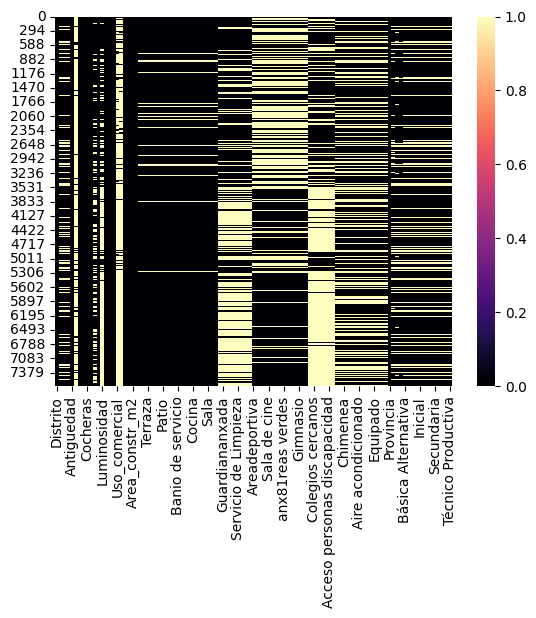

In [45]:
sns.heatmap(df.isna(), cmap='magma')

In [46]:
df.dropna(axis=1, thresh=0.8 * df.shape[0], inplace=True)
df.shape

(7631, 55)

In [47]:
df.dropna(subset='geometry', inplace=True)
df.shape

(6166, 55)

<Axes: >

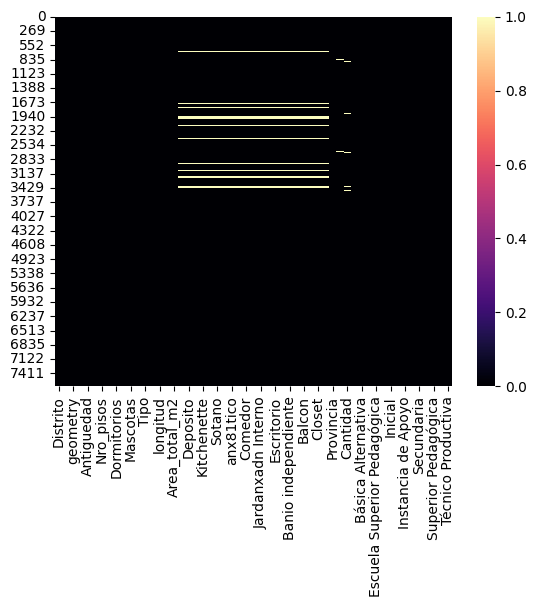

In [48]:
sns.heatmap(df.isna(), cmap='magma')

In [49]:
nulls = pd.DataFrame(df.isna().sum(axis=0), columns=['Nulos'])
nulls['pct'] = nulls['Nulos'] / df.shape[0]
nulls[nulls['Nulos'] > 0]

,Nulos,pct
Cuarto de servicio,183,2.97e-02
Deposito,183,2.97e-02
Terraza,183,2.97e-02
Kitchenette,183,2.97e-02
Sala de estar,183,2.97e-02
Sotano,183,2.97e-02
Patio,183,2.97e-02
anx81tico,183,2.97e-02
Comedor diario,183,2.97e-02
Comedor,183,2.97e-02


In [50]:
df.dropna(inplace=True)
df.shape

(5886, 55)

Tipo de dato

In [51]:
df.dtypes

,0
Distrito,object
poblacion,float64
geometry,geometry
geo_point_2d,object
Antiguedad,float64
NroBanios,float64
Nro_pisos,float64
Cocheras,float64
Dormitorios,object
Fecha_pub,object


In [52]:
df.select_dtypes(exclude=['object', 'geometry'])[0:1].T

,0
poblacion,166442.00
Antiguedad,5.00
NroBanios,4.00
Nro_pisos,2.00
Cocheras,3.00
Precio,885000.00
latitud,-12.08
longitud,-76.93
Area_constr_m2,450.00
Km2,65.80


In [53]:
integer_vars = df.select_dtypes(
    exclude=['object', 'geometry']).columns.drop(
        ['Precio', 'latitud', 'longitud', 'Km2', 'Empresas_por_km2'])
copy_temp = df[integer_vars].astype(np.int32)
df[integer_vars] = copy_temp
df.head()

,Distrito,poblacion,geometry,geo_point_2d,Antiguedad,NroBanios,Nro_pisos,Cocheras,Dormitorios,Fecha_pub,...,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
0,LaMolina,166442,"POLYGON ((-76.94449 -12.05684, -76.9441 -12.05...","{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",5,4,2,3,3,Publicado el 19.09.19,...,1,113,0,0,66,60,0,1,2,4
2,LaMolina,166442,"POLYGON ((-76.94449 -12.05684, -76.9441 -12.05...","{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",3,5,3,4,4,Publicado el 06.08.19,...,1,113,0,0,66,60,0,1,2,4
4,SantiagoDeSurco,410587,"POLYGON ((-76.95961 -12.07575, -76.95938 -12.0...","{ ""lon"": -76.984518805600004, ""lat"": -12.12722...",4,4,2,2,5,Publicado el 14.08.19,...,1,214,46,0,126,90,0,1,8,14
5,SanBorja,134317,"POLYGON ((-76.9872 -12.08007, -76.98711 -12.08...","{ ""lon"": -76.995262726899995, ""lat"": -12.09753...",1,5,3,2,5,Publicado el 22.08.19,...,1,57,2,1,25,20,0,0,4,5
7,VillaElSalvador,429509,"POLYGON ((-76.94163 -12.18351, -76.9416 -12.18...","{ ""lon"": -76.945441314099995, ""lat"": -12.21917...",5,5,2,1,5,Publicado el 02.09.19,...,0,278,182,0,247,152,0,2,5,13


In [54]:
df.select_dtypes(include='object')

,Distrito,geo_point_2d,Dormitorios,Fecha_pub,Mascotas,Tipo,Area_total_m2,Cuarto de servicio,Deposito,Terraza,...,Walking Closet,Escritorio,Cocina,Banio independiente,Lavanderanxada,Balcon,Sala,Closet,Banio de visitas,Provincia
0,LaMolina,"{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",3,Publicado el 19.09.19,Si,Casa,600.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Lima
2,LaMolina,"{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",4,Publicado el 06.08.19,Si,Casa,1518.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,Lima
4,SantiagoDeSurco,"{ ""lon"": -76.984518805600004, ""lat"": -12.12722...",5,Publicado el 14.08.19,Si,Casa,344.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,Lima
5,SanBorja,"{ ""lon"": -76.995262726899995, ""lat"": -12.09753...",5,Publicado el 22.08.19,Si,Casa,160.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,Lima
7,VillaElSalvador,"{ ""lon"": -76.945441314099995, ""lat"": -12.21917...",5,Publicado el 02.09.19,Si,Casa,173.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,Lima
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7658,SantiagoDeSurco,"{ ""lon"": -76.984518805600004, ""lat"": -12.12722...",5,Publicado el 20.08.19,Si,Casa,250.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,Lima
7659,LaMolina,"{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",4,Publicado el 20.08.19,Si,Casa,2640.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,Lima
7660,LaMolina,"{ ""lon"": -76.925898455099997, ""lat"": -12.08799...",5,Publicado el 20.08.19,Si,Casa en condominio,310.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,Lima
7661,SantiagoDeSurco,"{ ""lon"": -76.984518805600004, ""lat"": -12.12722...",4,Publicado el 20.08.19,Si,Casa,2650.0,1.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,Lima


In [55]:
integer_vars_2 = df.select_dtypes(include='object').columns.drop([
    'Fecha_pub', 'Mascotas', 'Tipo', 'Distrito', 'Provincia', 'geo_point_2d'])
for col in integer_vars_2:
  df.loc[:,col] = df.loc[:,col].apply(lambda x: int(float(x)))
df[integer_vars_2].head()

,Dormitorios,Area_total_m2,Cuarto de servicio,Deposito,Terraza,Kitchenette,Sala de estar,Sotano,Patio,anx81tico,...,Jardanxadn Interno,Walking Closet,Escritorio,Cocina,Banio independiente,Lavanderanxada,Balcon,Sala,Closet,Banio de visitas
0,3,600,1,1,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
2,4,1518,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
4,5,344,1,0,1,0,1,0,1,0,...,1,0,1,1,0,1,1,1,1,1
5,5,160,1,1,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
7,5,173,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [56]:
df.loc[:, 'Fecha_pub'] = df.loc[:, 'Fecha_pub'].apply(lambda x: datetime.strptime(x[13:],'%d.%m.%y'))

In [57]:
df.loc[:, 'Mascotas'] = np.where(df['Mascotas'] == 'Si', 1, 0)

In [58]:
obj_cols = ['Fecha_pub', 'Tipo', 'Distrito', 'Provincia']
float_cols = ['Precio', 'latitud', 'longitud', 'Km2', 'Empresas_por_km2']
geo_cols = ['geometry', 'geo_point_2d']
integer_cols = df.columns.drop(obj_cols + float_cols + geo_cols)
df[integer_cols] = df[integer_cols].astype(np.int16)
df[float_cols] = df[float_cols].astype(np.float32)

In [59]:
df.dtypes

,0
Distrito,object
poblacion,int16
geometry,geometry
geo_point_2d,object
Antiguedad,int16
NroBanios,int16
Nro_pisos,int16
Cocheras,int16
Dormitorios,int16
Fecha_pub,object


Outliers

<Axes: xlabel='Precio'>

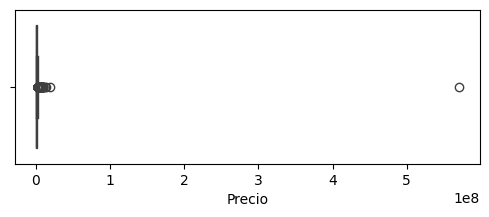

In [60]:
plt.figure(figsize=(6, 2))
sns.boxplot(df, x='Precio')

In [61]:
q1 = df['Precio'].quantile(0.25)
q3 = df['Precio'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df = df[df['Precio'] <= ul]
df.shape

(5566, 55)

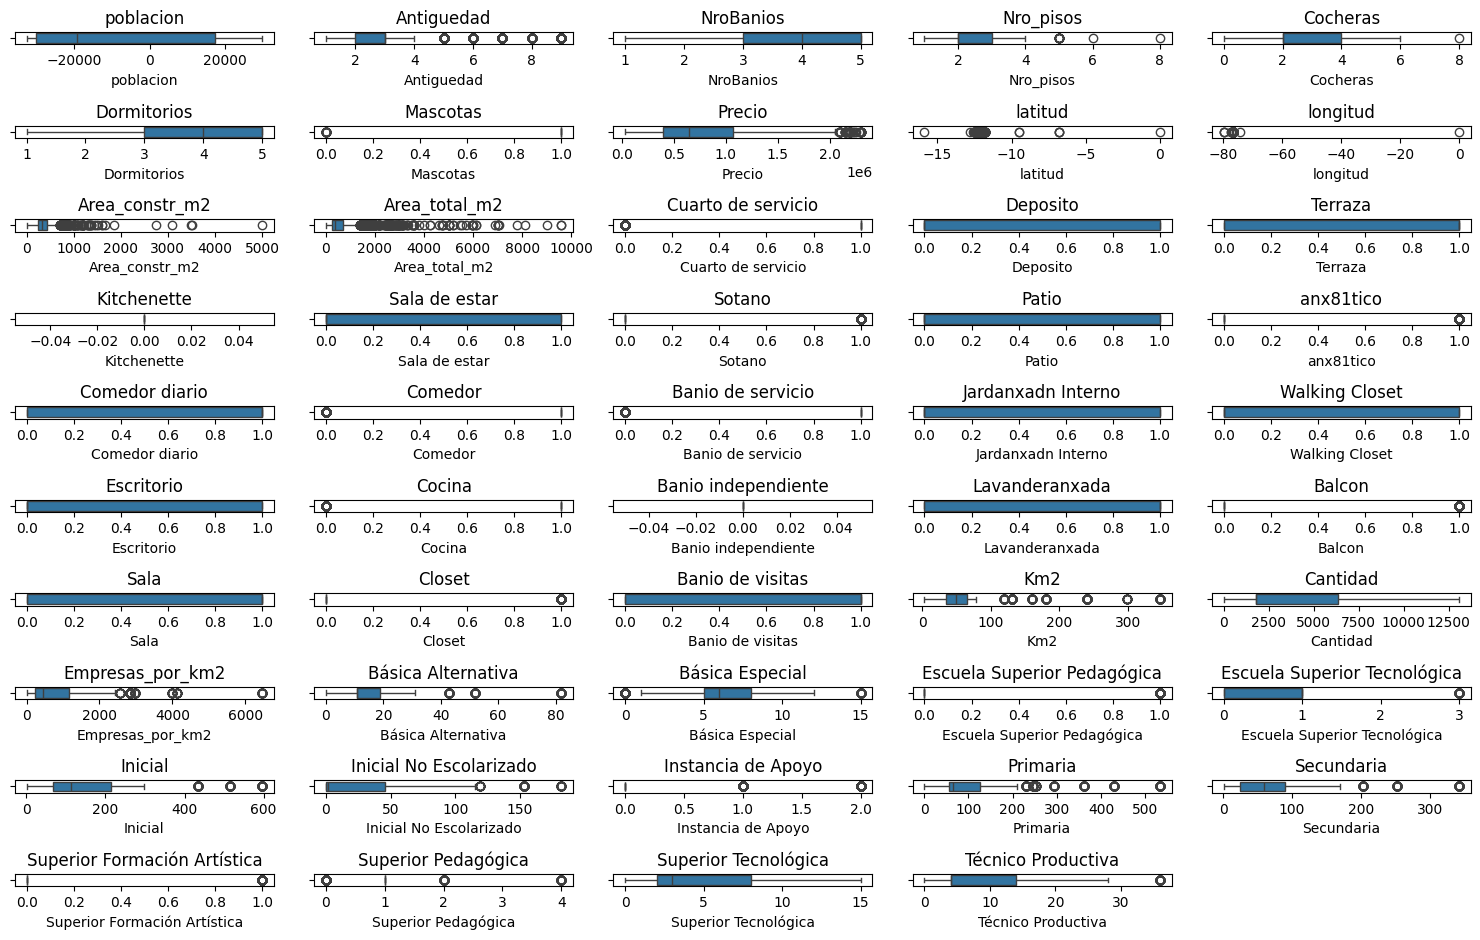

In [62]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(exclude=['object', 'geometry']).columns):
    plt.subplot(11, 5, i + 1)  # Ajusta el número de subplots según la cantidad de columnas
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [63]:
df['Nro_pisos'].value_counts()

,count
Nro_pisos,
2,3191
3,1827
1,398
4,132
5,16
6,1
8,1


In [64]:
df['Nro_pisos'] = np.where(df['Nro_pisos'] >= 5, 5, df['Nro_pisos'])

In [65]:
df['Cocheras'].value_counts()

,count
Cocheras,
2,1998
4,893
3,858
1,719
5,592
0,504
6,1
8,1


In [66]:
df = df[df["Cocheras"] < 6]
df.shape

(5564, 55)

In [67]:
# TBD: queda madiana o winsorización
q1 = df['Area_constr_m2'].quantile(0.25)
q3 = df['Area_constr_m2'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Area_constr_m2'] >= ul, 'Area_constr_m2'] = df['Area_constr_m2'].median()

In [68]:
# TBD: queda madiana o winsorización
q1 = df['Area_total_m2'].quantile(0.25)
q3 = df['Area_total_m2'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Area_total_m2'] >= ul, 'Area_total_m2'] = df['Area_total_m2'].median()

In [69]:
df['Básica Alternativa'].value_counts()

,count
Básica Alternativa,
11,2232
19,969
4,459
7,348
12,293
20,243
0,158
8,115
82,90


In [70]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Básica Alternativa y los reemplazamos por la mediana
q1 = df['Básica Alternativa'].quantile(0.25)
q3 = df['Básica Alternativa'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Básica Alternativa'] >= ul, 'Básica Alternativa'] = df['Básica Alternativa'].median()

In [71]:
df['Básica Especial'].value_counts()

,count
Básica Especial,
6,2157
12,954
0,578
8,472
4,351
7,340
2,298
5,154
3,99


In [72]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Básica Especial y los reemplazamos por la mediana
q1 = df['Básica Especial'].quantile(0.25)
q3 = df['Básica Especial'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Básica Especial'] >= ul, 'Básica Especial'] = df['Básica Especial'].median()

In [73]:
#Variable trinaria, no se retiran outliers
df['Escuela Superior Tecnológica'].value_counts()

,count
Escuela Superior Tecnológica,
1,3692
0,1782
3,90


In [74]:
df['Inicial'].value_counts()

,count
Inicial,
113,2162
214,954
37,360
55,270
210,243
57,202
121,115
25,99
596,90


In [75]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Inicial y los reemplazamos por la mediana
q1 = df['Inicial'].quantile(0.25)
q3 = df['Inicial'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Inicial'] >= ul, 'Inicial'] = df['Inicial'].median()

In [76]:
df['Inicial No Escolarizado'].value_counts()

,count
Inicial No Escolarizado,
0,2596
46,992
3,270
2,268
75,243
17,115
10,99
153,90
8,88


In [77]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Inicial y los reemplazamos por la mediana
q1 = df['Inicial No Escolarizado'].quantile(0.25)
q3 = df['Inicial No Escolarizado'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Inicial No Escolarizado'] >= ul, 'Inicial No Escolarizado'] = df['Inicial No Escolarizado'].median()

In [78]:
#Variable trinaria, no se retiran outliers
df['Instancia de Apoyo'].value_counts()

,count
Instancia de Apoyo,
0,4865
1,540
2,159


In [79]:
#Representa cuántas instituciones de nivel Primaria hay en el distrito
df['Primaria'].value_counts()

,count
Primaria,
66,2210
126,954
19,360
28,270
167,243
25,202
21,127
68,115
533,90


In [80]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Inicial y los reemplazamos por la mediana
q1 = df['Primaria'].quantile(0.25)
q3 = df['Primaria'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Primaria'] >= ul, 'Primaria'] = df['Primaria'].median()

In [81]:
#Representa cuántas instituciones de nivel Secundaria hay en el distrito
df['Secundaria'].value_counts()

,count
Secundaria,
60,2157
90,954
18,360
25,348
95,243
20,202
53,115
12,99
342,90


In [82]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Inicial y los reemplazamos por la mediana
q1 = df['Secundaria'].quantile(0.25)
q3 = df['Secundaria'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Secundaria'] >= ul, 'Secundaria'] = df['Secundaria'].median()

In [83]:
#Variable binaria, no se quitan outliers
df['Superior Formación Artística'].value_counts()

,count
Superior Formación Artística,
0,5394
1,170


In [84]:
#No se quitan outliers solo se tienen 4 casos en la variable
df['Superior Pedagógica'].value_counts()

,count
Superior Pedagógica,
1,4070
0,1307
2,97
4,90


In [85]:
df['Técnico Productiva'].value_counts()

,count
Técnico Productiva,
4,2318
14,954
11,360
0,338
13,304
16,265
5,208
8,153
9,123


In [86]:
# TBD: queda madiana o winsorización
#Quitamos outliers de Inicial y los reemplazamos por la mediana
q1 = df['Técnico Productiva'].quantile(0.25)
q3 = df['Técnico Productiva'].quantile(0.75)
iqr = q3 - q1
ul = q3 + 1.5*iqr
df.loc[df['Técnico Productiva'] >= ul, 'Técnico Productiva'] = df['Técnico Productiva'].median()

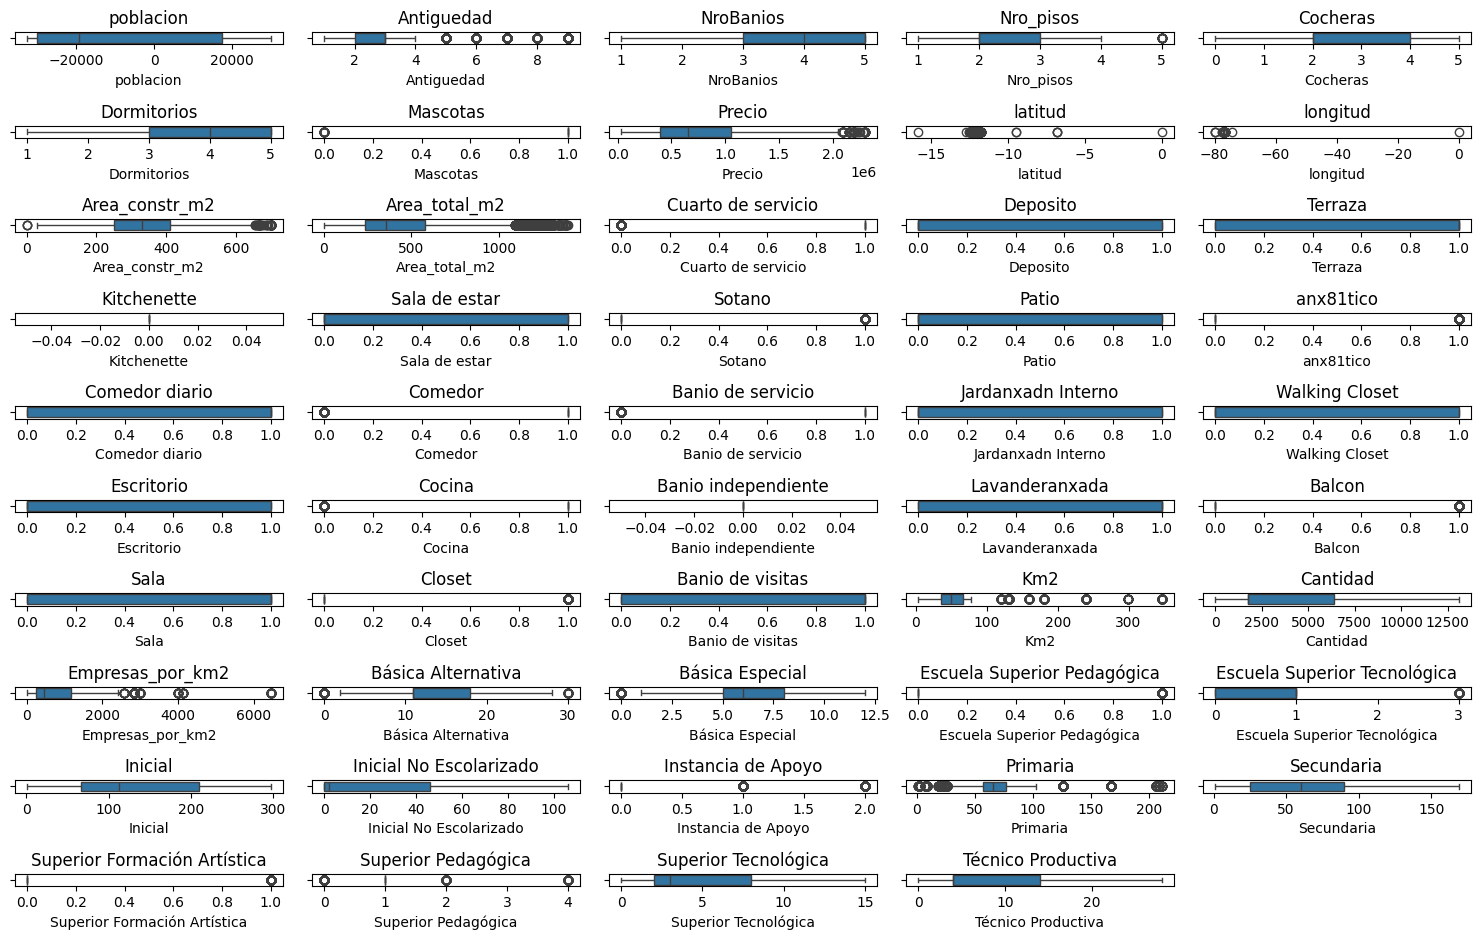

In [87]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(exclude=['object', 'geometry']).columns):
    plt.subplot(11, 5, i + 1)  # Ajusta el número de subplots según la cantidad de columnas
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# **Grafiquitos**

<Axes: xlabel='poblacion', ylabel='Count'>

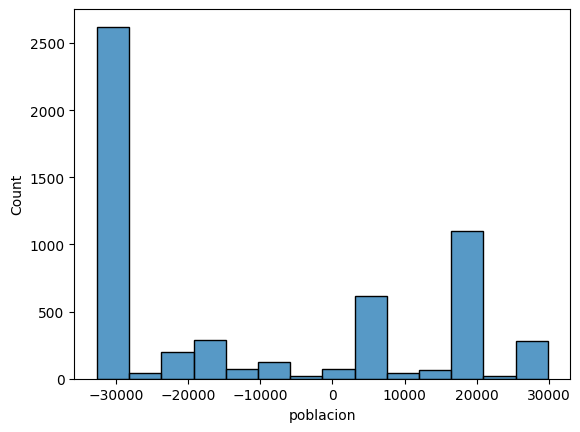

In [ ]:
sns.histplot(df, x='poblacion')

<Axes: xlabel='Antiguedad', ylabel='count'>

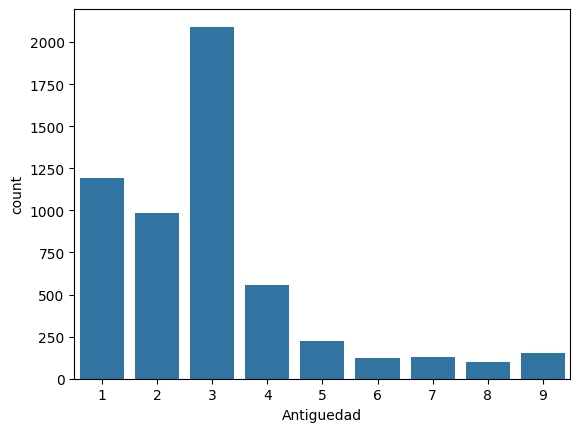

In [ ]:
sns.countplot(df, x='Antiguedad')

<Axes: xlabel='NroBanios', ylabel='count'>

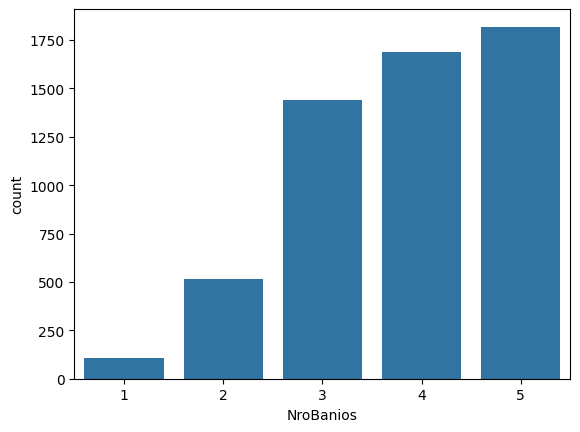

In [ ]:
sns.countplot(df, x='NroBanios')

<Axes: xlabel='Nro_pisos', ylabel='count'>

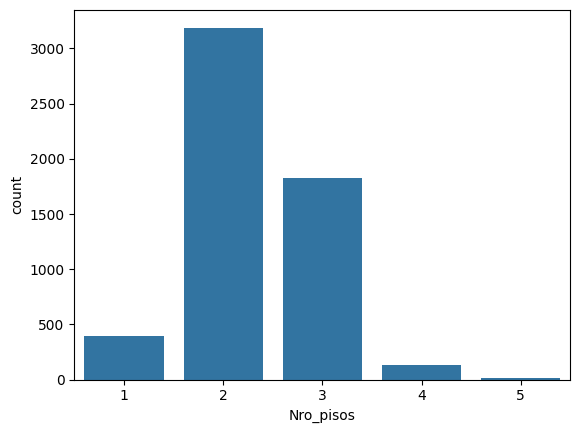

In [ ]:
sns.countplot(df, x='Nro_pisos')

<Axes: xlabel='Cocheras', ylabel='count'>

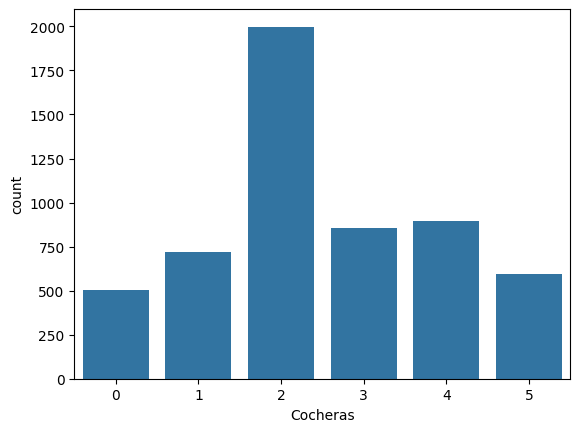

In [ ]:
sns.countplot(df, x='Cocheras')

<Axes: xlabel='Dormitorios', ylabel='count'>

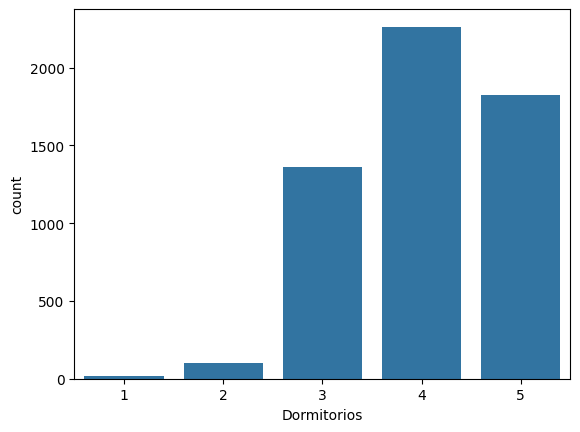

In [ ]:
sns.countplot(df, x='Dormitorios')

<Axes: xlabel='Area_constr_m2', ylabel='Count'>

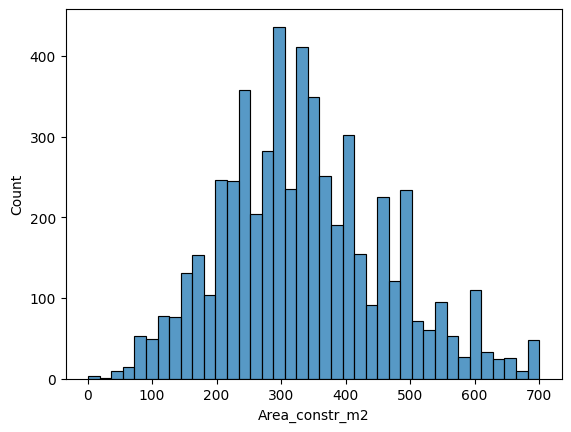

In [ ]:
sns.histplot(df, x='Area_constr_m2')

<Axes: xlabel='Area_total_m2', ylabel='Count'>

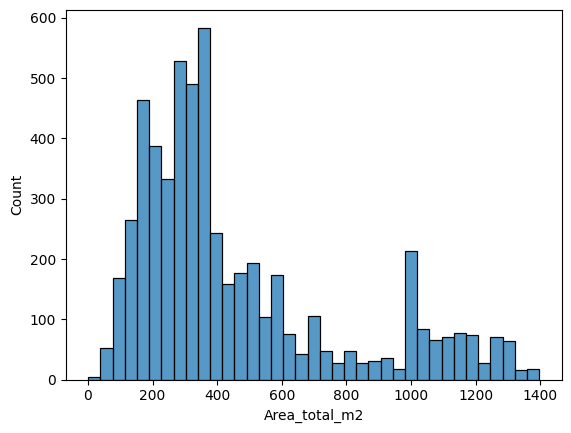

In [ ]:
sns.histplot(df, x='Area_total_m2')

<Axes: xlabel='Km2', ylabel='Count'>

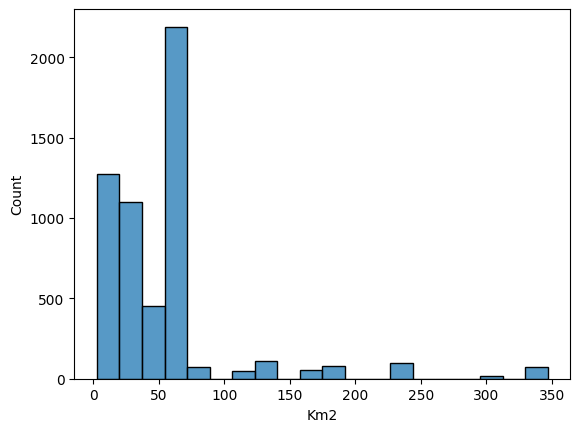

In [ ]:
sns.histplot(df, x='Km2', bins=20)

<Axes: xlabel='Cantidad', ylabel='Count'>

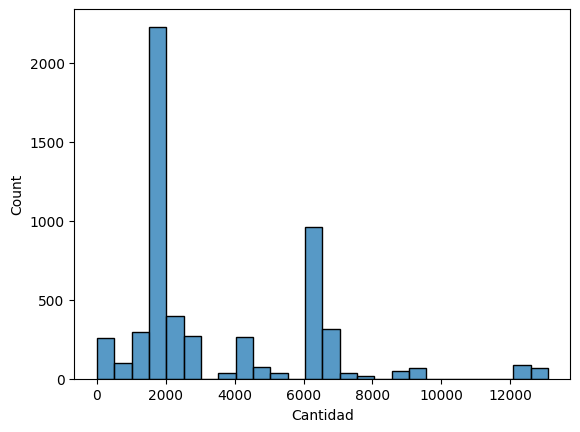

In [ ]:
sns.histplot(df, x='Cantidad')

<Axes: xlabel='Empresas_por_km2', ylabel='Count'>

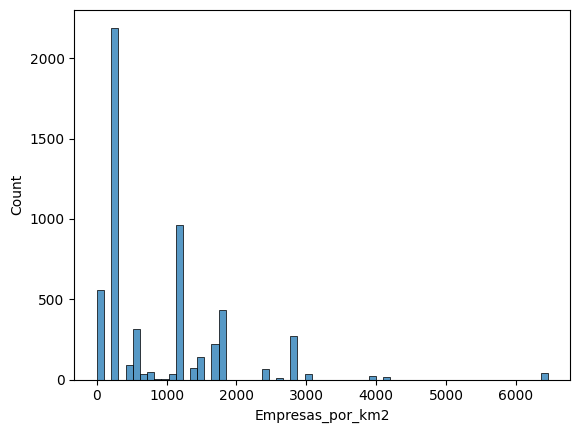

In [ ]:
sns.histplot(df, x='Empresas_por_km2')

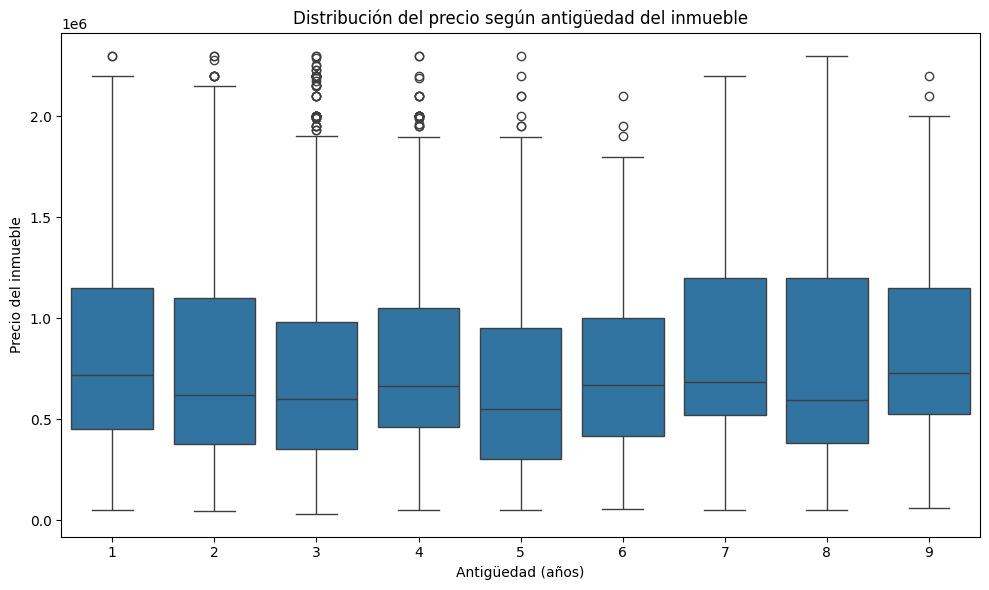

In [89]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Antiguedad", y="Precio")

plt.title("Distribución del precio según antigüedad del inmueble")
plt.xlabel("Antigüedad (años)")
plt.ylabel("Precio del inmueble")
plt.tight_layout()
plt.show()


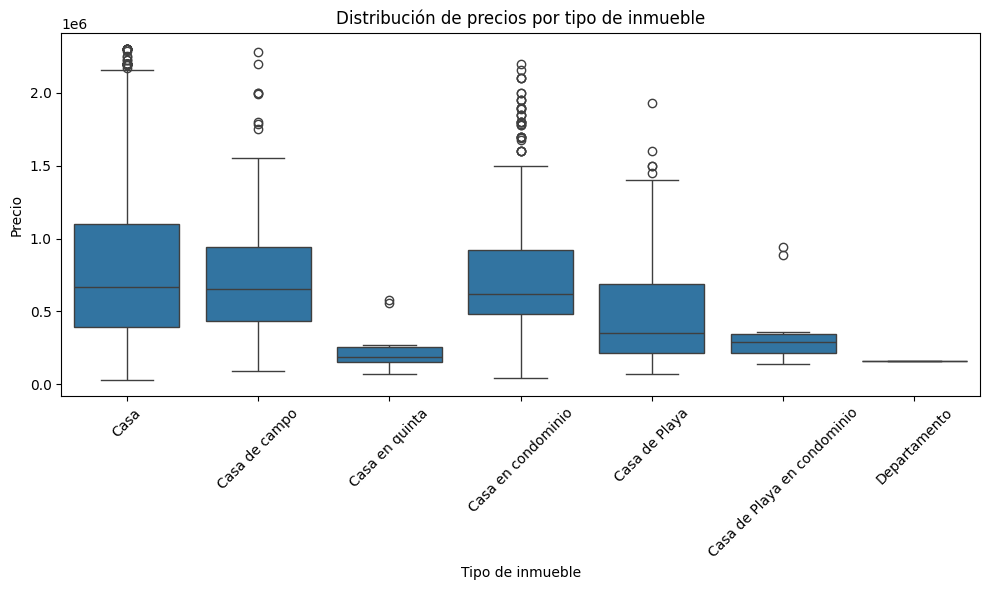

In [90]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tipo', y='Precio')
plt.title("Distribución de precios por tipo de inmueble")
plt.xlabel("Tipo de inmueble")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Transformación**

In [ ]:
df.columns

Index(['Distrito', 'poblacion', 'geometry', 'geo_point_2d', 'Antiguedad',
       'NroBanios', 'Nro_pisos', 'Cocheras', 'Dormitorios', 'Fecha_pub',
       'Mascotas', 'Precio', 'Tipo', 'latitud', 'longitud', 'Area_constr_m2',
       'Area_total_m2', 'Cuarto de servicio', 'Deposito', 'Terraza',
       'Kitchenette', 'Sala de estar', 'Sotano', 'Patio', 'anx81tico',
       'Comedor diario', 'Comedor', 'Banio de servicio', 'Jardanxadn Interno',
       'Walking Closet', 'Escritorio', 'Cocina', 'Banio independiente',
       'Lavanderanxada', 'Balcon', 'Sala', 'Closet', 'Banio de visitas',
       'Provincia', 'Km2', 'Cantidad', 'Empresas_por_km2',
       'Básica Alternativa', 'Básica Especial', 'Escuela Superior Pedagógica',
       'Escuela Superior Tecnológica', 'Inicial', 'Inicial No Escolarizado',
       'Instancia de Apoyo', 'Primaria', 'Secundaria',
       'Superior Formación Artística', 'Superior Pedagógica',
       'Superior Tecnológica', 'Técnico Productiva'],
      dtype='object')

In [ ]:
df1 = df[df.columns.drop(['Distrito', 'Provincia', 'geometry', 'geo_point_2d', 'latitud', 'longitud', 'Fecha_pub'])]
min_max_cols = ['poblacion', 'Antiguedad', 'NroBanios', 'Dormitorios', 'Precio', 'Area_total_m2',
                'Km2', 'Cantidad', 'Empresas_por_km2']
standard_cols = ['Nro_pisos', 'Cocheras', 'Area_constr_m2',
                 'Básica Alternativa', 'Básica Especial',
                 'Escuela Superior Pedagógica', 'Escuela Superior Tecnológica',
                 'Inicial', 'Inicial No Escolarizado', 'Instancia de Apoyo',
                 'Primaria', 'Secundaria', 'Superior Formación Artística',
                 'Superior Pedagógica', 'Superior Tecnológica',
                 'Técnico Productiva']
df1.head()

,poblacion,Antiguedad,NroBanios,Nro_pisos,Cocheras,Dormitorios,Mascotas,Precio,Tipo,Area_constr_m2,...,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
0,-30166,5,4,2,3,3,1,8.85e+05,Casa,450,...,1,113,0,0,66,60,0,1,2,4
2,-30166,3,5,3,4,4,1,1.95e+06,Casa,625,...,1,113,0,0,66,60,0,1,2,4
4,17371,4,4,2,2,5,1,5.90e+05,Casa,290,...,1,214,46,0,126,90,0,1,8,14
5,3245,1,5,3,2,5,1,3.80e+05,Casa,300,...,1,57,2,1,25,20,0,0,4,5
7,-29243,5,5,2,1,5,1,7.50e+04,Casa,173,...,0,278,182,0,247,152,0,2,5,13


In [ ]:
minmax, stdscaler = MinMaxScaler(), StandardScaler()
df1.loc[:, min_max_cols] = minmax.fit_transform(df1[min_max_cols])
df1.loc[:, standard_cols] = stdscaler.fit_transform(df1[standard_cols])
df1.head()

,poblacion,Antiguedad,NroBanios,Nro_pisos,Cocheras,Dormitorios,Mascotas,Precio,Tipo,Area_constr_m2,...,Escuela Superior Tecnológica,Inicial,Inicial No Escolarizado,Instancia de Apoyo,Primaria,Secundaria,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva
0,0.04,0.50,0.75,-0.48,0.36,0.50,1,0.38,Casa,0.88,...,0.52,-0.27,-0.66,-0.36,-0.31,-0.16,-0.18,0.28,-0.72,-0.68
2,0.04,0.25,1.00,1.05,1.07,0.75,1,0.85,Casa,2.26,...,0.52,-0.27,-0.66,-0.36,-0.31,-0.16,-0.18,0.28,-0.72,-0.68
4,0.80,0.38,0.75,-0.48,-0.34,1.00,1,0.25,Casa,-0.37,...,0.52,0.69,0.59,-0.36,0.34,0.39,-0.18,0.28,0.88,0.81
5,0.57,0.00,1.00,1.05,-0.34,1.00,1,0.15,Casa,-0.29,...,0.52,-0.80,-0.61,1.95,-0.76,-0.89,-0.18,-1.37,-0.19,-0.53
7,0.05,0.50,1.00,-0.48,-1.05,1.00,1,0.02,Casa,-1.29,...,-1.30,1.30,4.30,-0.36,1.65,1.53,-0.18,1.92,0.08,0.66


In [ ]:
onehot = pd.get_dummies(df1['Tipo'], drop_first=True).astype(np.int8)
df1.drop(columns=['Tipo'], inplace=True)
df1 = pd.concat([df1, onehot], axis=1)
df1.head()

,poblacion,Antiguedad,NroBanios,Nro_pisos,Cocheras,Dormitorios,Mascotas,Precio,Area_constr_m2,Area_total_m2,...,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva,Casa de Playa,Casa de Playa en condominio,Casa de campo,Casa en condominio,Casa en quinta,Departamento
0,0.04,0.50,0.75,-0.48,0.36,0.50,1,0.38,0.88,0.43,...,-0.18,0.28,-0.72,-0.68,0,0,0,0,0,0
2,0.04,0.25,1.00,1.05,1.07,0.75,1,0.85,2.26,0.25,...,-0.18,0.28,-0.72,-0.68,0,0,0,0,0,0
4,0.80,0.38,0.75,-0.48,-0.34,1.00,1,0.25,-0.37,0.25,...,-0.18,0.28,0.88,0.81,0,0,0,0,0,0
5,0.57,0.00,1.00,1.05,-0.34,1.00,1,0.15,-0.29,0.11,...,-0.18,-1.37,-0.19,-0.53,0,0,0,0,0,0
7,0.05,0.50,1.00,-0.48,-1.05,1.00,1,0.02,-1.29,0.12,...,-0.18,1.92,0.08,0.66,0,0,0,0,0,0


<Axes: >

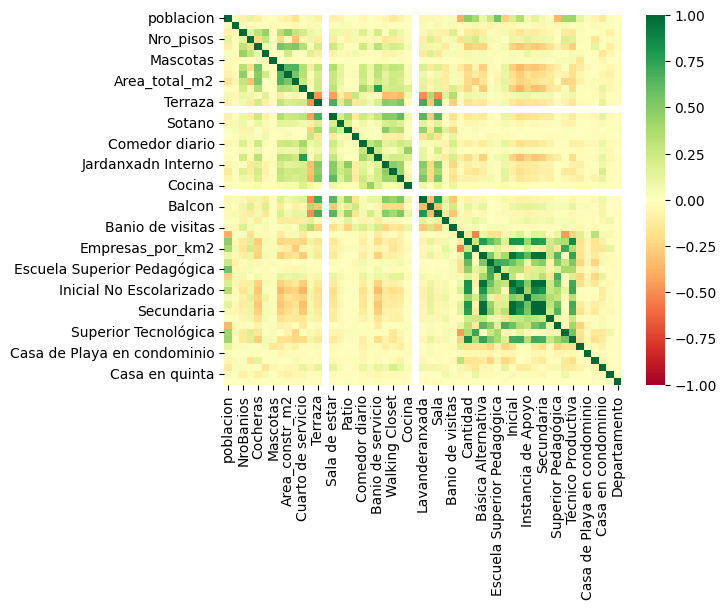

In [ ]:
sns.heatmap(df1.corr(), cmap='RdYlGn', vmax=1, vmin=-1)

# **Split**

In [ ]:
X = df1.drop(columns=['Precio'])
y = df1['Precio']
X.shape, y.shape

((5564, 52), (5564,))

In [ ]:
X

,poblacion,Antiguedad,NroBanios,Nro_pisos,Cocheras,Dormitorios,Mascotas,Area_constr_m2,Area_total_m2,Cuarto de servicio,...,Superior Formación Artística,Superior Pedagógica,Superior Tecnológica,Técnico Productiva,Casa de Playa,Casa de Playa en condominio,Casa de campo,Casa en condominio,Casa en quinta,Departamento
0,0.04,0.50,0.75,-0.48,0.36,0.50,1,0.88,0.43,1,...,-0.18,0.28,-0.72,-0.68,0,0,0,0,0,0
2,0.04,0.25,1.00,1.05,1.07,0.75,1,2.26,0.25,1,...,-0.18,0.28,-0.72,-0.68,0,0,0,0,0,0
4,0.80,0.38,0.75,-0.48,-0.34,1.00,1,-0.37,0.25,1,...,-0.18,0.28,0.88,0.81,0,0,0,0,0,0
5,0.57,0.00,1.00,1.05,-0.34,1.00,1,-0.29,0.11,1,...,-0.18,-1.37,-0.19,-0.53,0,0,0,0,0,0
7,0.05,0.50,1.00,-0.48,-1.05,1.00,1,-1.29,0.12,0,...,-0.18,1.92,0.08,0.66,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7656,0.21,0.12,0.75,-0.48,1.77,1.00,1,-0.26,0.38,0,...,-0.18,0.28,-0.99,-1.27,0,0,1,0,0,0
7657,0.64,0.50,1.00,-0.48,1.07,1.00,1,-0.06,0.47,1,...,-0.18,-1.37,1.15,0.37,0,0,0,0,0,0
7658,0.80,0.12,0.50,-0.48,0.36,1.00,1,-1.47,0.18,1,...,-0.18,0.28,0.88,0.81,0,0,0,0,0,0
7660,0.04,0.25,1.00,-0.48,0.36,1.00,1,-0.43,0.22,1,...,-0.18,0.28,-0.72,-0.68,0,0,0,1,0,0


<Axes: xlabel='Precio', ylabel='Count'>

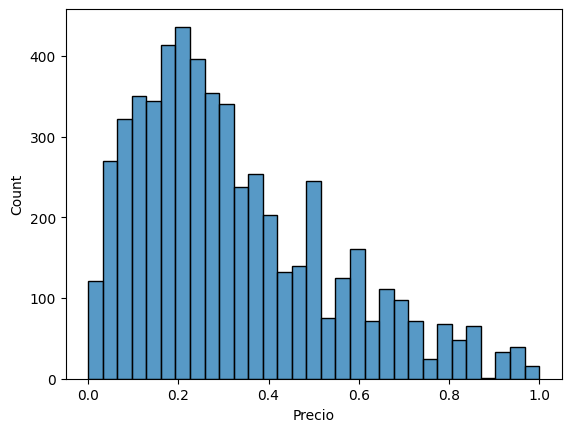

In [ ]:
sns.histplot(y)